Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Kolom yang dihapus: ['id']

        count
floors       
1       10680
2        8241
15       1910
3         613
25        161
35          8
0.13.2


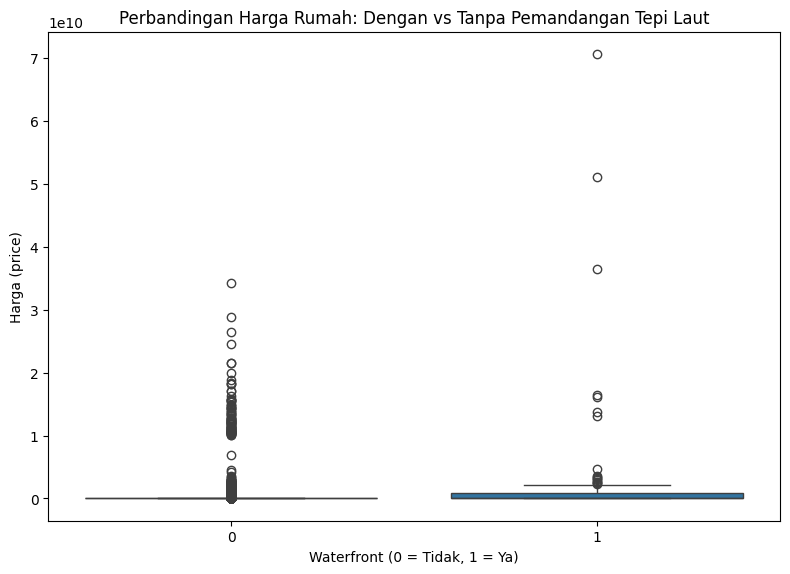

Boxplot berhasil ditampilkan!



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


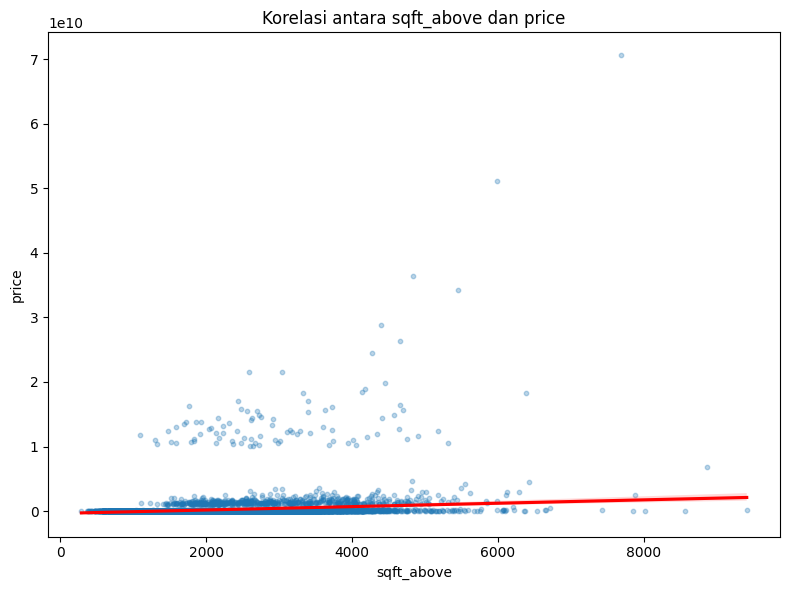

Regplot berhasil ditampilkan!
Intercept  : -457275133.3928
Koefisien  : 272937.8290
R² Score   : 0.0467
Fitur yang digunakan: ['floors', 'waterfront', 'lat', 'bedrooms', 'sqft_basement', 'view', 'bathrooms', 'sqft_living15', 'sqft_above', 'grade', 'sqft_living']
R² Score (multi-fitur): 0.0638
Pipeline berhasil dibuat dan disesuaikan!
Langkah Pipeline: [('scaler', 'StandardScaler'), ('model', 'LinearRegression')]
R² Score (Pipeline): 0.0638
Ridge Regression (alpha=0.1)
R² Train : 0.0666
R² Test  : 0.0394
Polynomial (degree=2) + Ridge Regression (alpha=0.1)
R² Train : 0.2233
R² Test  : -0.1376


In [25]:
!pip install pandas
!pip install numpy matplotlib
!pip install seaborn

import pandas as pd
df=pd.read_csv('kc_house_data1.csv', sep=';')
df.head()

df.dtypes

cols_to_drop = [c for c in ['id', 'Unnamed: 0'] if c in df.columns]
df.drop(cols_to_drop, axis=1, inplace=True)
print(f'Kolom yang dihapus: {cols_to_drop}')
print()
df.describe()

floors_vc = df['floors'].value_counts().to_frame()
floors_vc.columns = ['count']
floors_vc.index.name = 'floors'
print(floors_vc)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(sns.__version__)

df['price']= pd.to_numeric(df['price'], errors='coerce')
df= df.dropna(subset=['price'])


plt.figure(figsize=(8, 6))
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('Perbandingan Harga Rumah: Dengan vs Tanpa Pemandangan Tepi Laut')
plt.xlabel('Waterfront (0 = Tidak, 1 = Ya)')
plt.ylabel('Harga (price)')
plt.tight_layout()
plt.savefig('plot_1_4_boxplot_waterfront.png', dpi=100)
plt.show()
print('Boxplot berhasil ditampilkan!')

!pip install scikit-learn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
plt.figure(figsize=(8, 6))
sns.regplot(x='sqft_above', y='price', data=df,
            scatter_kws={'alpha': 0.3, 's': 10},
            line_kws={'color': 'red'})
plt.title('Korelasi antara sqft_above dan price')
plt.xlabel('sqft_above')
plt.ylabel('price')
plt.tight_layout()
plt.savefig('plot_1_5_regplot_sqft_above.png', dpi=100)
plt.show()
print('Regplot berhasil ditampilkan!')

X_1 = df[['sqft_living']]
y = df['price']

lm1 = LinearRegression()
lm1.fit(X_1, y)
r2_1 = lm1.score(X_1, y)

print(f'Intercept  : {lm1.intercept_:.4f}')
print(f'Koefisien  : {lm1.coef_[0]:.4f}')
print(f'R² Score   : {r2_1:.4f}')

features = ['floors', 'waterfront', 'lat', 'bedrooms', 'sqft_basement',
            'view', 'bathrooms', 'sqft_living15', 'sqft_above', 'grade',
            'sqft_living']

X_2 = df[features]
y = df['price']

lm2 = LinearRegression()
lm2.fit(X_2, y)
r2_2 = lm2.score(X_2, y)

print(f'Fitur yang digunakan: {features}')
print(f'R² Score (multi-fitur): {r2_2:.4f}')

features_pipe = ['floors', 'waterfront', 'lat', 'bedrooms', 'sqft_basement',
                 'view', 'bathrooms', 'sqft_living15', 'sqft_above', 'grade',
                 'sqft_living']

X_pipe = df[features_pipe]
y = df['price']

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_pipe, y)
r2_pipe = pipeline.score(X_pipe, y)

print('Pipeline berhasil dibuat dan disesuaikan!')
print(f'Langkah Pipeline: {[(name, type(step).__name__) for name, step in pipeline.steps]}')
print(f'R² Score (Pipeline): {r2_pipe:.4f}')

features_ridge = ['floors', 'waterfront', 'lat', 'bedrooms', 'sqft_basement',
                  'view', 'bathrooms', 'sqft_living15', 'sqft_above', 'grade',
                  'sqft_living']

X_ridge = df[features_ridge]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X_ridge, y, test_size=0.2, random_state=1)

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

r2_train = ridge.score(X_train, y_train)
r2_test = ridge.score(X_test, y_test)

print(f'Ridge Regression (alpha=0.1)')
print(f'R² Train : {r2_train:.4f}')
print(f'R² Test  : {r2_test:.4f}')

features_poly = ['floors', 'waterfront', 'lat', 'bedrooms', 'sqft_basement',
                 'view', 'bathrooms', 'sqft_living15', 'sqft_above', 'grade',
                 'sqft_living']

X_poly_data = df[features_poly]
y = df['price']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly_data, y, test_size=0.2, random_state=1)

# Pipeline: PolynomialFeatures -> StandardScaler -> Ridge
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=0.1))
])

poly_pipeline.fit(X_train_p, y_train_p)

r2_poly_train = poly_pipeline.score(X_train_p, y_train_p)
r2_poly_test = poly_pipeline.score(X_test_p, y_test_p)

print('Polynomial (degree=2) + Ridge Regression (alpha=0.1)')
print(f'R² Train : {r2_poly_train:.4f}')
print(f'R² Test  : {r2_poly_test:.4f}')